In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os


# Color Test

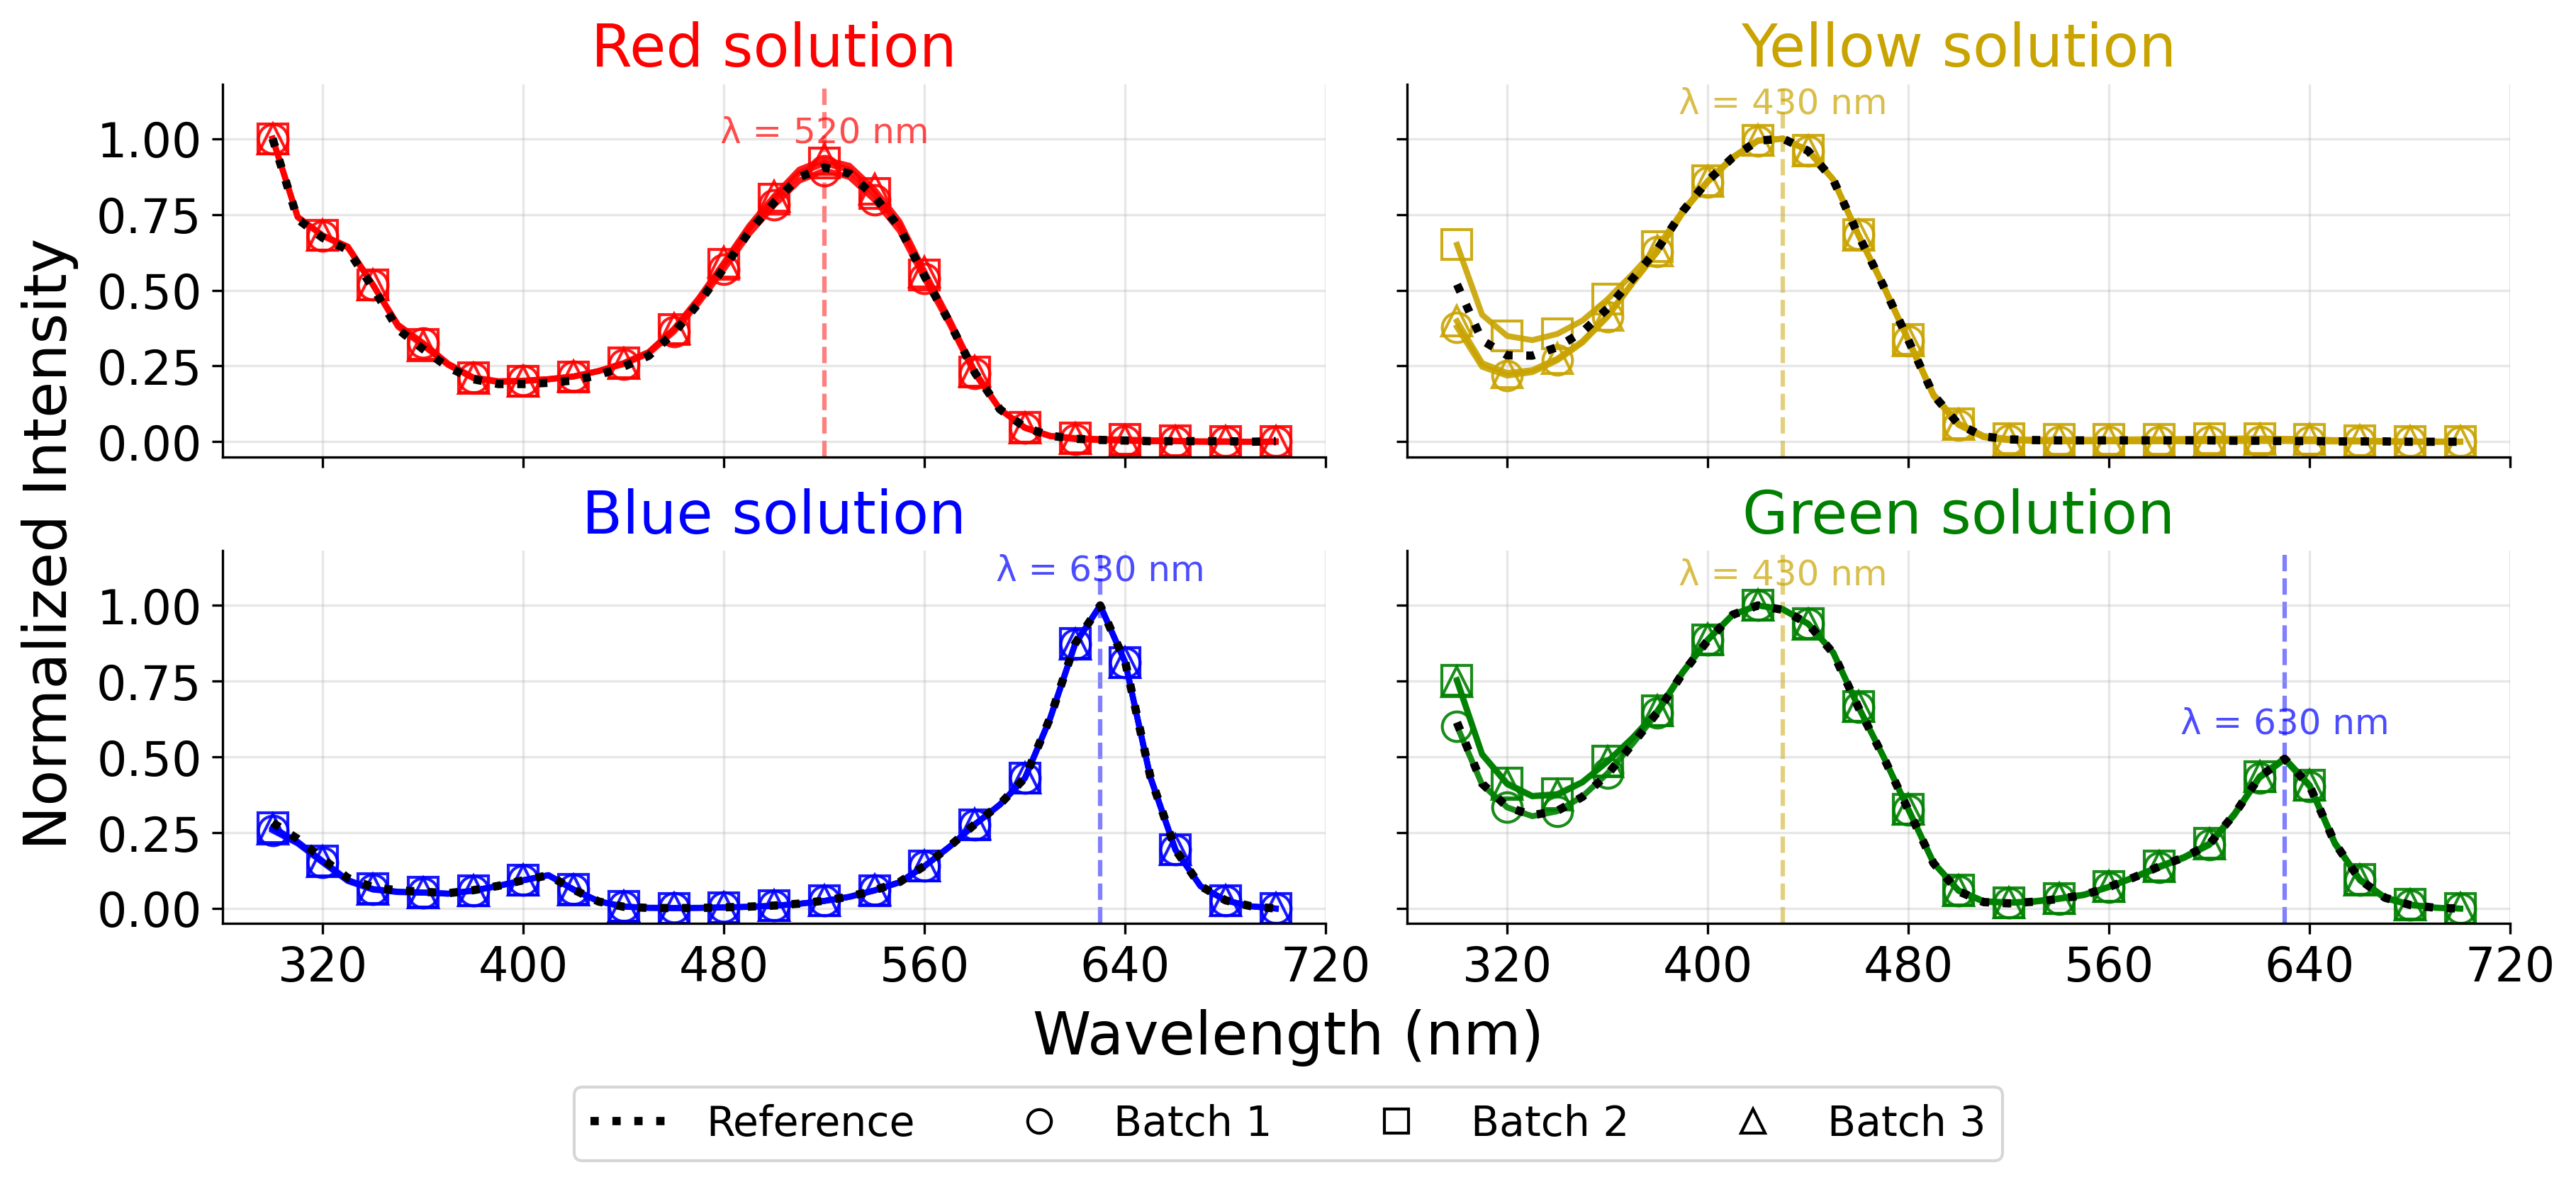

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# Load
df = pd.read_csv("Fractions_August19_2025.csv")
w = df["Wavelength"].values

solution_colors = {
    "E": "blue",
    "F": "green",
    "G": "red",
    "H": "#C9A300"  # darker gold/yellow for better visibility
}

panel_titles = {"E": "Blue", "F": "Green", "G": "Red", "H": "Yellow"}
batch_cols = ["1","3","5"]
batch_labels = {"1":"Batch 1","3":"Batch 2","5":"Batch 3"}
batch_markers = {"1":"o","3":"s","5":"^"}
ref_suffix = "12"

def minmax_normalize(y):
    y = np.asarray(y, float)
    r = y.max() - y.min()
    return (y - y.min())/r if r != 0 else np.zeros_like(y)

def find_peak_xy(wl, y, lo=350, hi=700):
    m = (wl>=lo) & (wl<=hi)
    if not np.any(m): return None
    i = np.nanargmax(y[m])
    return float(wl[m][i]), float(y[m][i])

fig, axes = plt.subplots(2,2, figsize=(12,5), sharex=True, sharey=True, constrained_layout=True, dpi = 300, facecolor='white')
axes = axes.flatten()
mark_every = max(len(w)//20, 1)

for i, base in enumerate(["G","H","E","F"]):
    ax = axes[i]

    # Reference
    ref_col = f"{base}{ref_suffix}"
    if ref_col in df.columns:
        y_ref = minmax_normalize(df[ref_col].values)
        ax.plot(w, y_ref, color="black", linestyle=":", linewidth=2.8,
                label="Reference", zorder=3)

        if base == "F":  # Green panel: show yellow@420 and blue@630
            # (target_nm, color_key)
            for target, ckey in [(430, "H"), (630, "E")]:
                idx = (np.abs(w - target)).argmin()
                px, py = w[idx], y_ref[idx]
                ax.axvline(px, color=solution_colors[ckey],
                        linewidth=1.5, linestyle="--", zorder=1, alpha=0.5)
                ax.text(px, min(py + 0.06, 1.1), f"λ = {int(round(px))} nm",
                        ha="center", va="bottom", fontsize=12,
                        color=solution_colors[ckey], alpha=0.7)
        else:
            # Other panels: line + label in the panel's own color
            pk = find_peak_xy(w, y_ref, lo=340, hi=720)
            if pk:
                px, py = pk
                ax.axvline(px, color=solution_colors[base],
                        linewidth=1.5, linestyle="--", zorder=1, alpha=0.5)
                ax.text(px, min(py + 0.06, 1.1), f"λ = {int(round(px))} nm",
                        ha="center", va="bottom", fontsize=12,
                        color=solution_colors[base], alpha=0.7)

    # Batches
    for b in batch_cols:
        col = f"{base}{b}"
        if col in df.columns:
            y = minmax_normalize(df[col].values)
            ax.plot(
                w, y,
                color=solution_colors[base],        # line color
                marker=batch_markers[b],
                markevery=mark_every,
                linewidth=2.0,
                alpha=0.9,
                label=batch_labels[b],
                zorder=2,
                markerfacecolor='none',             # <-- hollow markers
                markeredgecolor=solution_colors[base],
                markersize=10
            )


    ax.set_title(f"{panel_titles[base]} solution", fontsize=20, pad=6, c = solution_colors[base])
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.05, 1.18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.tick_params(labelsize=16)

fig.supxlabel("Wavelength (nm)", fontsize=20)
fig.supylabel("Normalized Intensity", fontsize=20)

handles = [Line2D([0],[0], color="black", linestyle=":", lw=2.8, label="Reference")] + [
    Line2D([0],[0],
           color="black",
           marker=batch_markers[b],
           linestyle="None",
           lw=2,
           label=batch_labels[b],
           markerfacecolor='none',
           markeredgecolor="black",
           markersize=8)
    for b in batch_cols
]

fig.legend(handles=handles, loc="lower center", ncol=4,
           fontsize=14, bbox_to_anchor=(0.5, -0.1))

plt.show()


# Volume Accuracy

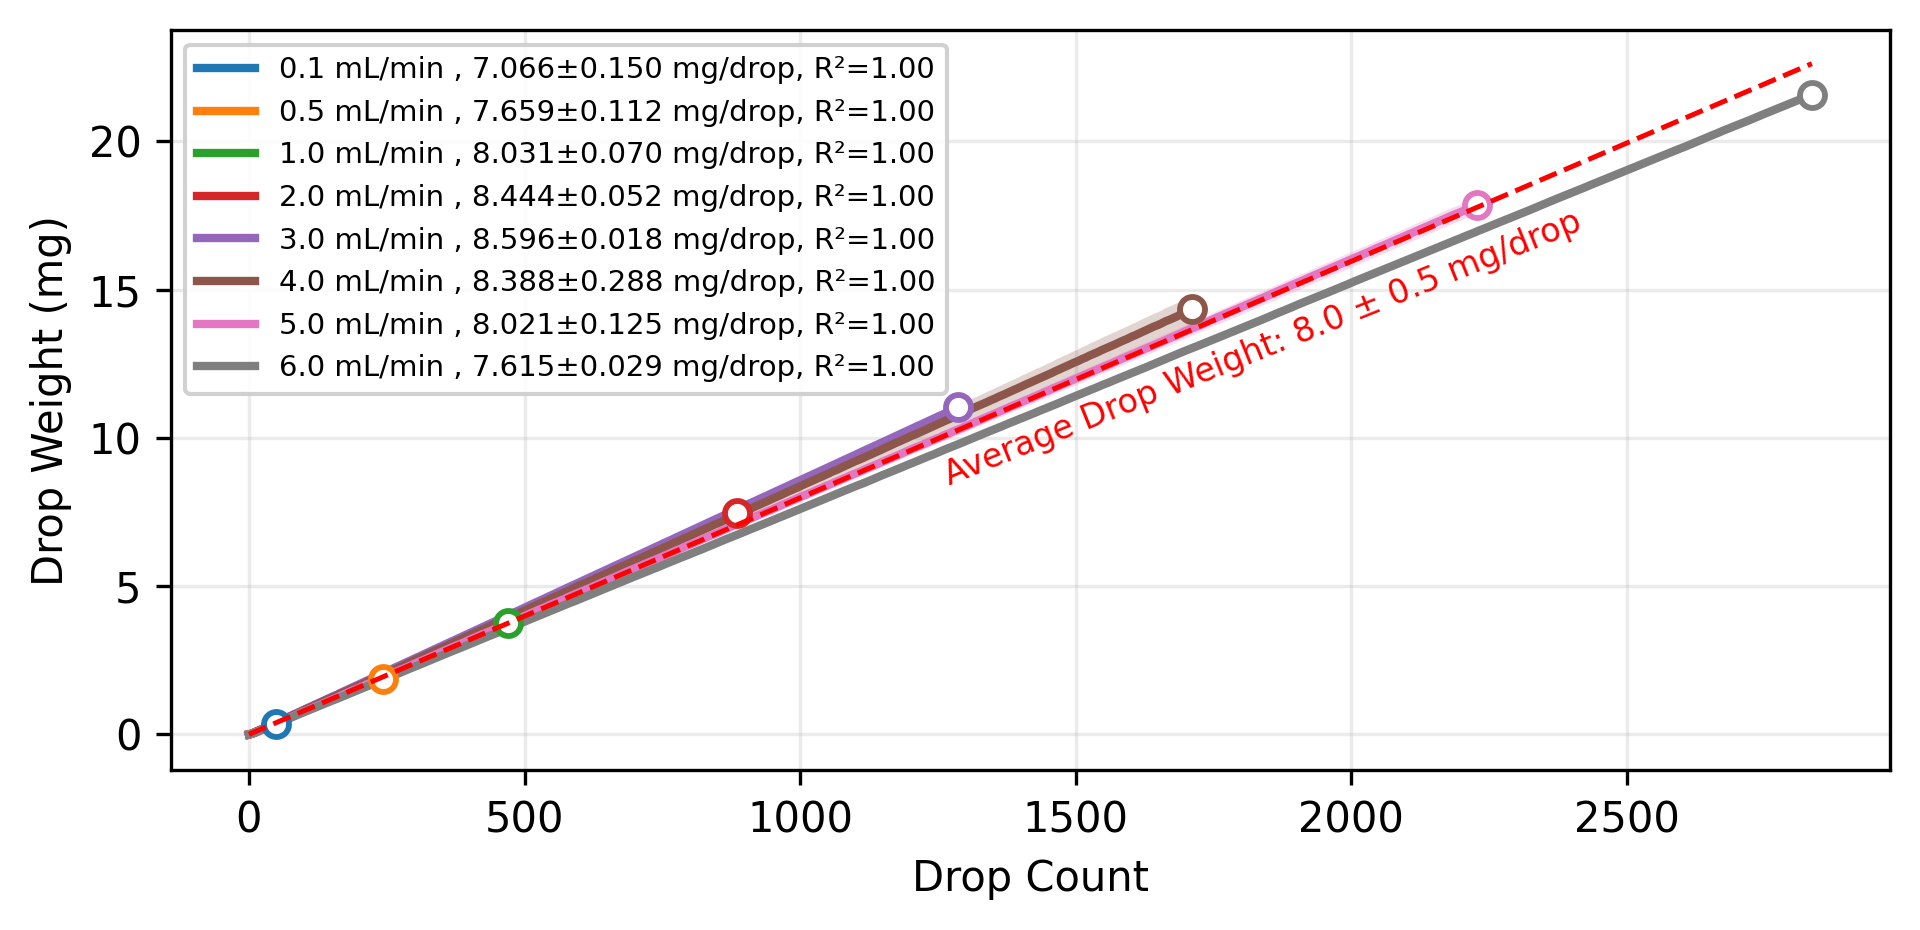

In [3]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# === File List (edit as needed) ===
csv_files = [
    "viscosity_accuracy_0.1ml_per_min_IPA_small_1.csv",
    "viscosity_accuracy_0.1ml_per_min_IPA_small_2.csv",
    "viscosity_accuracy_0.1ml_per_min_IPA_small_3.csv",
    "viscosity_accuracy_0.1ml_per_min_IPA_small_4.csv",
    "viscosity_accuracy_0.5ml_per_min_IPA_small_1.csv",
    "viscosity_accuracy_0.5ml_per_min_IPA_small_2.csv",
    "viscosity_accuracy_0.5ml_per_min_IPA_small_3.csv",
    "viscosity_accuracy_0.5ml_per_min_IPA_small_4.csv",
    "viscosity_accuracy_1ml_per_min_IPA_small_1.csv",
    "viscosity_accuracy_1ml_per_min_IPA_small_2.csv",
    "viscosity_accuracy_1ml_per_min_IPA_small_3.csv",
    "viscosity_accuracy_1ml_per_min_IPA_small_4.csv",
    "viscosity_accuracy_2ml_per_min_IPA_small_1.csv",
    "viscosity_accuracy_2ml_per_min_IPA_small_2.csv",
    "viscosity_accuracy_2ml_per_min_IPA_small_3.csv",
    "viscosity_accuracy_2ml_per_min_IPA_small_4.csv",
    "viscosity_accuracy_3ml_per_min_IPA_small_1.csv",
    "viscosity_accuracy_3ml_per_min_IPA_small_2.csv",
    "viscosity_accuracy_3ml_per_min_IPA_small_3.csv",
    "viscosity_accuracy_3ml_per_min_IPA_small_4.csv",
    "viscosity_accuracy_4ml_per_min_IPA_small_1.csv",
    "viscosity_accuracy_4ml_per_min_IPA_small_2.csv",
    "viscosity_accuracy_4ml_per_min_IPA_small_3.csv",
    "viscosity_accuracy_4ml_per_min_IPA_small_4.csv",
    "viscosity_accuracy_5ml_per_min_IPA_small_1.csv",
    "viscosity_accuracy_5ml_per_min_IPA_small_2.csv",
    "viscosity_accuracy_5ml_per_min_IPA_small_3.csv",
    "viscosity_accuracy_5ml_per_min_IPA_small_4.csv",
    "viscosity_accuracy_6ml_per_min_IPA_small_1.csv",
    "viscosity_accuracy_6ml_per_min_IPA_small_2.csv",
    "viscosity_accuracy_6ml_per_min_IPA_small_3.csv",
    "viscosity_accuracy_6ml_per_min_IPA_small_4.csv"
]

# --- Helpers ---
def _linfit_r2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2:
        return np.nan, np.nan, np.nan
    a, b = np.polyfit(x[m], y[m], 1)
    yhat = a * x[m] + b
    ss_res = np.sum((y[m] - yhat) ** 2)
    ss_tot = np.sum((y[m] - y[m].mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    return a, b, r2

def _parse_flowrate_from_filename(file):
    """Extract numeric flowrate from names like '..._0.5ml_per_min_...csv'."""
    basename = os.path.basename(file)
    m = re.search(r"viscosity_accuracy_([\d\.]+)ml_per_min", basename)
    return float(m.group(1)) if m else None

def _get_drop_series(df):
    for col in ["drop_counter", "vernier_drop", "drops"]:
        if col in df.columns:
            return pd.to_numeric(df[col], errors="coerce").ffill().fillna(0)
    raise KeyError("No drop counter column found (expected 'drop_counter' or 'vernier_drop' or 'drops').")

def _first_drop_index(drops: pd.Series) -> int:
    d = drops.to_numpy()
    diffs = np.diff(d, prepend=d[0])
    pos = np.flatnonzero(diffs > 0)
    return int(pos[0]) if len(pos) else 0

# --- Plotting (grouped) ---
def plot_weight_vs_drops_grouped(files, n_points=250):
    def _clean_xy(drops, weight):
        m = np.isfinite(drops) & np.isfinite(weight)
        x = drops[m].astype(float)
        y = weight[m].astype(float)
        if x.size < 2:
            return np.array([]), np.array([])
        order = np.argsort(x)
        x, y = x[order], y[order]
        x_unique, idx_start = np.unique(x, return_index=True)
        counts = np.diff(np.r_[idx_start, x.size])
        y_sums = np.add.reduceat(y, idx_start)
        y_unique = y_sums / counts
        if x_unique.size < 2:
            return np.array([]), np.array([])
        return x_unique, y_unique

    fig, ax = plt.subplots(figsize=(6.5, 3.2), facecolor="white", dpi=300)
    ax.set_facecolor("white")
    ax.set_axisbelow(True)
    ax.grid(True, alpha=0.25, linewidth=0.8)

    # --- collect curves by flowrate ---
    grouped = {}
    for file in files:
        if not os.path.exists(file):
            print(f"[WARN] File not found: {file}")
            continue
        df = pd.read_csv(file)
        if "timestamp" not in df.columns or "weight" not in df.columns:
            print(f"[WARN] Missing required columns in {file}; skipping.")
            continue

        flow = _parse_flowrate_from_filename(file)
        if flow is None:
            print(f"[WARN] Could not parse flowrate from {file}")
            continue

        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        weight = pd.to_numeric(df["weight"], errors="coerce")
        drops  = _get_drop_series(df)

        # align to ~1 s before first drop
        i_first = _first_drop_index(drops)
        first_ts = df["timestamp"].iloc[i_first] if i_first < len(df) else df["timestamp"].dropna().iloc[0]
        if pd.isna(first_ts):
            first_ts = df["timestamp"].dropna().iloc[0]
        start_ts = first_ts - pd.Timedelta(seconds=1)
        start_idx = int(df["timestamp"].searchsorted(start_ts, side="left"))
        if start_idx >= len(df) - 1:
            print(f"[WARN] Not enough data in {file}; skipping.")
            continue

        drops  = drops.iloc[start_idx:].reset_index(drop=True) - drops.iloc[start_idx]
        weight = weight.iloc[start_idx:].reset_index(drop=True)

        x_u, y_u = _clean_xy(drops.to_numpy(), weight.to_numpy())
        if x_u.size < 2:
            print(f"[WARN] Curve too short after cleaning: {file}")
            continue

        a, b, r2 = _linfit_r2(x_u, y_u)
        grouped.setdefault(flow, []).append({"x": x_u, "y": y_u, "slope": a, "r2": r2})

    if not grouped:
        print("No valid data found.")
        return

    # fixed color per flowrate
    flows = sorted(grouped.keys())
    cmap = plt.get_cmap("tab10")
    color_for = {f: cmap(i % 10) for i, f in enumerate(flows)}

    handles, labels = [], []
    all_slopes = []                 # <-- collect for overall average
    global_xmin, global_xmax = np.inf, -np.inf  # <-- track x-limits used

    for flow in flows:
        reps = grouped[flow]
        if not reps:
            continue

        # common grid limited to coverage of all replicates
        xmax_common = np.min([np.nanmax(r["x"]) for r in reps])
        if not np.isfinite(xmax_common) or xmax_common <= 0:
            continue
        x = np.linspace(0.0, xmax_common, n_points)

        Ys, slopes, r2s = [], [], []
        for r in reps:
            Ys.append(np.interp(x, r["x"], r["y"]))
            if np.isfinite(r["slope"]): slopes.append(r["slope"])
            if np.isfinite(r["r2"]):    r2s.append(r["r2"])

        Y = np.vstack(Ys)
        y_mean = Y.mean(axis=0)
        y_std  = Y.std(axis=0, ddof=1) if Y.shape[0] > 1 else np.zeros_like(y_mean)

        # ensure band visible even if std≈0
        y_rng = max(1e-9, float(y_mean.max() - y_mean.min()))
        y_std = np.maximum(y_std, 0.003 * y_rng)

        c = color_for[flow]
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, color=c, alpha=0.25, lw=0, zorder=1)
        line, = ax.plot(x, y_mean, color=c, lw=2.0, zorder=2)
        ax.plot([x[-1]], [y_mean[-1]], "o", mfc="white", mec=c, mew=1.4, ms=6, zorder=3)

        # legend text
        n = Y.shape[0]
        slope_txt = ""
        if slopes:
            s_mean = np.mean(slopes)
            s_std  = np.std(slopes, ddof=1) if len(slopes) > 1 else 0.0
            slope_txt = f", {s_mean*1000:.3f}±{s_std*1000:.3f} mg/drop"
        r2_txt = f", R²={np.mean(r2s):.2f}" if r2s else ""
        handles.append(line)
        labels.append(f"{flow:.1f} mL/min {slope_txt}{r2_txt}")

        # --- for overall average line/annotation ---
        all_slopes.extend(slopes)
        global_xmin = min(global_xmin, float(x[0]))
        global_xmax = max(global_xmax, float(x[-1]))

    # === RED OVERALL-AVERAGE LINE + ANGLED ANNOTATION ===
    valid_slopes = np.array([s for s in all_slopes if np.isfinite(s)], dtype=float)
    if valid_slopes.size and np.isfinite(global_xmin) and np.isfinite(global_xmax) and global_xmax > global_xmin:
        a_avg = float(valid_slopes.mean())                         # g/drop
        a_std = float(valid_slopes.std(ddof=1)) if valid_slopes.size > 1 else 0.0

        xline = np.linspace(global_xmin, global_xmax, 200)
        yline = a_avg * xline
        ax.plot(xline, yline, "r--", lw=1.2, zorder=10)

        # pick an annotation point and rotate text along the line (display coords)
        x_annot = global_xmin + 0.45 * (global_xmax - global_xmin)
        y_annot = a_avg * x_annot - 2  # shift slightly down; tweak if needed

        fig.canvas.draw()  # ensure transforms are current
        dx = 0.2 * (global_xmax - global_xmin)
        p1 = ax.transData.transform((x_annot, y_annot))
        p2 = ax.transData.transform((x_annot + dx, y_annot + a_avg * dx))
        angle_deg = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))

        ax.text(
            x_annot, y_annot,
            f"Average Drop Weight: {a_avg*1000:.1f} ± {a_std*1000:.1f} mg/drop",
            color="red", fontsize=8, rotation=angle_deg-4, rotation_mode="anchor",
            va="bottom", ha="left", zorder=11,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0, lw=0)
        )
    # ====================================================

    ax.set_xlabel("Drop Count")
    ax.set_ylabel("Drop Weight (mg)")
    #ax.set_title("Collection Accuracy at Different Flowrates", fontsize=10)
    if handles:
        ax.legend(handles, labels, fontsize=7, framealpha=0.9, loc="best")
    plt.tight_layout()
    plt.show()
plot_weight_vs_drops_grouped(csv_files)

Flow rate: 0.1 mL/min, Replicate 1
  Slope: 7.150 mg/drop
  Percent Error: 1.18%
  R²: 1.00

Flow rate: 0.1 mL/min, Replicate 2
  Slope: 7.233 mg/drop
  Percent Error: 2.37%
  R²: 1.00

Flow rate: 0.1 mL/min, Replicate 3
  Slope: 6.915 mg/drop
  Percent Error: 2.13%
  R²: 1.00

Flow rate: 0.1 mL/min, Replicate 4
  Slope: 6.966 mg/drop
  Percent Error: 1.42%
  R²: 1.00

Flow rate: 0.1 mL/min, Coefficient of Variation (CV): 2.13%

Flow rate: 0.5 mL/min, Replicate 1
  Slope: 7.821 mg/drop
  Percent Error: 2.11%
  R²: 1.00

Flow rate: 0.5 mL/min, Replicate 2
  Slope: 7.576 mg/drop
  Percent Error: 1.08%
  R²: 1.00

Flow rate: 0.5 mL/min, Replicate 3
  Slope: 7.645 mg/drop
  Percent Error: 0.18%
  R²: 1.00

Flow rate: 0.5 mL/min, Replicate 4
  Slope: 7.594 mg/drop
  Percent Error: 0.85%
  R²: 1.00

Flow rate: 0.5 mL/min, Coefficient of Variation (CV): 1.46%

Flow rate: 1.0 mL/min, Replicate 1
  Slope: 8.103 mg/drop
  Percent Error: 0.89%
  R²: 1.00

Flow rate: 1.0 mL/min, Replicate 2
  Slop

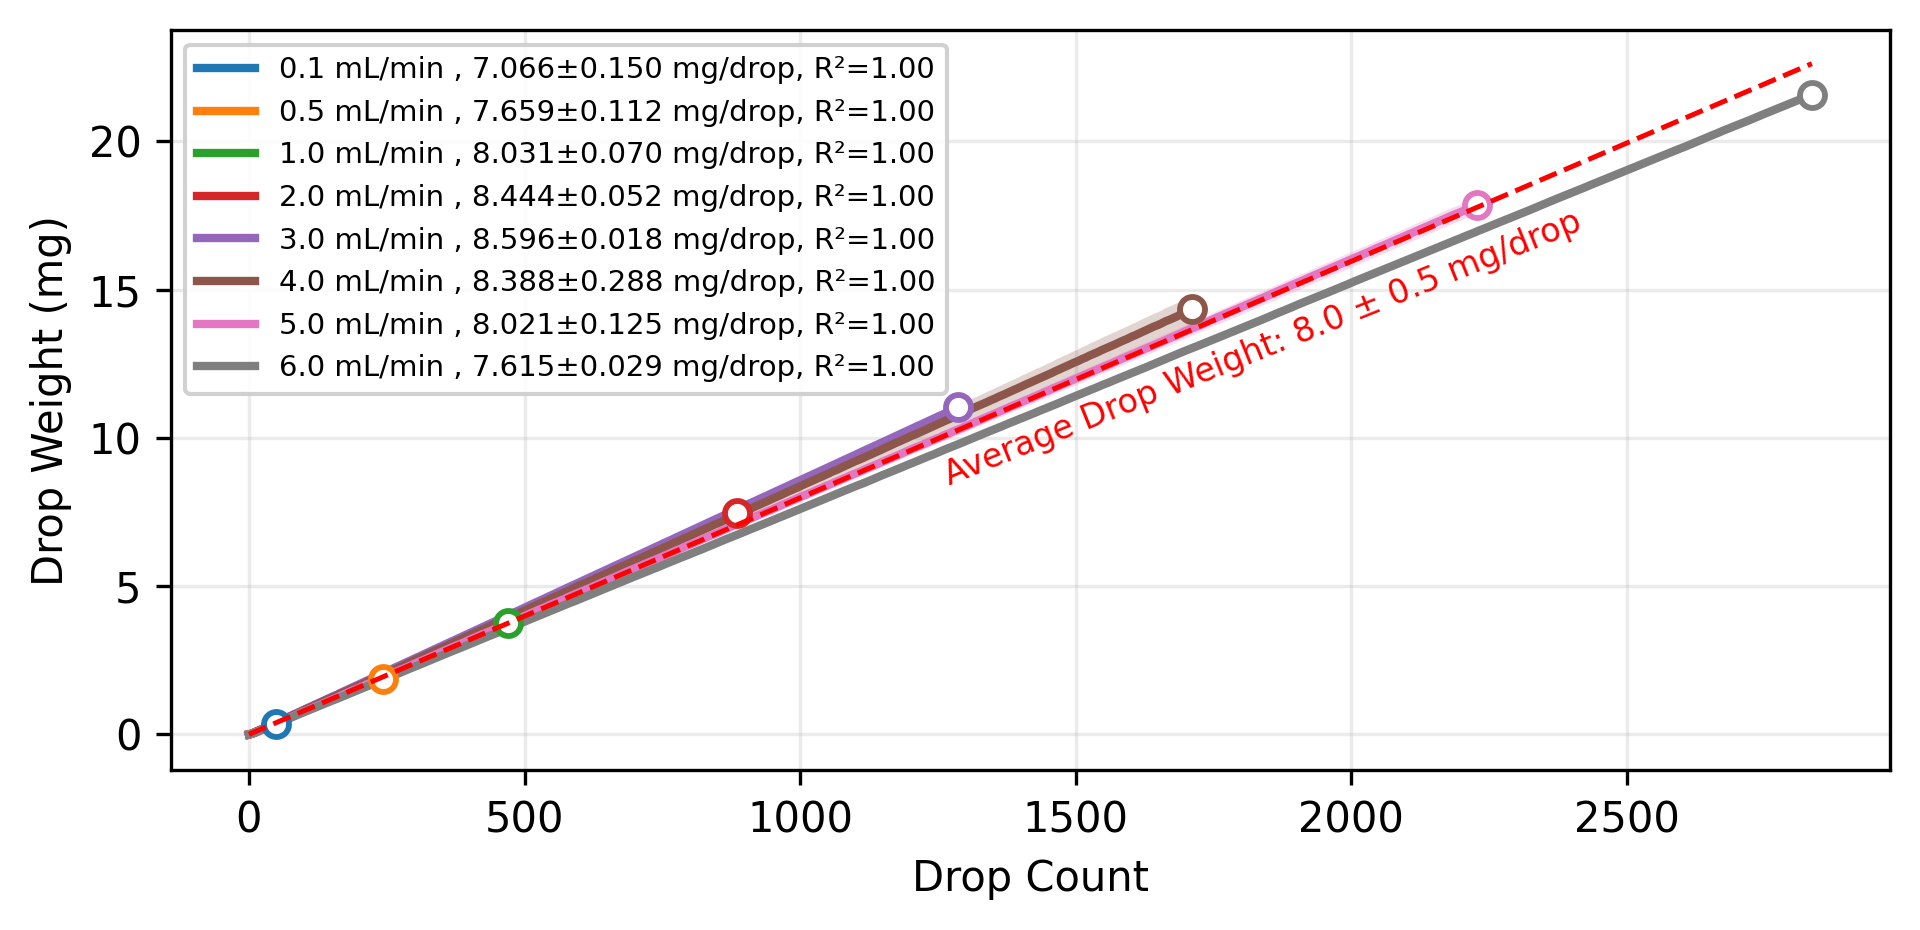

In [4]:
def plot_weight_vs_drops_grouped(files, n_points=250):
    def _clean_xy(drops, weight):
        m = np.isfinite(drops) & np.isfinite(weight)
        x = drops[m].astype(float)
        y = weight[m].astype(float)
        if x.size < 2:
            return np.array([]), np.array([])
        order = np.argsort(x)
        x, y = x[order], y[order]
        x_unique, idx_start = np.unique(x, return_index=True)
        counts = np.diff(np.r_[idx_start, x.size])
        y_sums = np.add.reduceat(y, idx_start)
        y_unique = y_sums / counts
        if x_unique.size < 2:
            return np.array([]), np.array([])
        return x_unique, y_unique

    fig, ax = plt.subplots(figsize=(6.5, 3.2), facecolor="white", dpi=300)
    ax.set_facecolor("white")
    ax.set_axisbelow(True)
    ax.grid(True, alpha=0.25, linewidth=0.8)

    # --- collect curves by flowrate ---
    grouped = {}
    for file in files:
        if not os.path.exists(file):
            print(f"[WARN] File not found: {file}")
            continue
        df = pd.read_csv(file)
        if "timestamp" not in df.columns or "weight" not in df.columns:
            print(f"[WARN] Missing required columns in {file}; skipping.")
            continue

        flow = _parse_flowrate_from_filename(file)
        if flow is None:
            print(f"[WARN] Could not parse flowrate from {file}")
            continue

        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        weight = pd.to_numeric(df["weight"], errors="coerce")
        drops  = _get_drop_series(df)

        # align to ~1 s before first drop
        i_first = _first_drop_index(drops)
        first_ts = df["timestamp"].iloc[i_first] if i_first < len(df) else df["timestamp"].dropna().iloc[0]
        if pd.isna(first_ts):
            first_ts = df["timestamp"].dropna().iloc[0]
        start_ts = first_ts - pd.Timedelta(seconds=1)
        start_idx = int(df["timestamp"].searchsorted(start_ts, side="left"))
        if start_idx >= len(df) - 1:
            print(f"[WARN] Not enough data in {file}; skipping.")
            continue

        drops  = drops.iloc[start_idx:].reset_index(drop=True) - drops.iloc[start_idx]
        weight = weight.iloc[start_idx:].reset_index(drop=True)

        x_u, y_u = _clean_xy(drops.to_numpy(), weight.to_numpy())
        if x_u.size < 2:
            print(f"[WARN] Curve too short after cleaning: {file}")
            continue

        a, b, r2 = _linfit_r2(x_u, y_u)
        grouped.setdefault(flow, []).append({"x": x_u, "y": y_u, "slope": a, "r2": r2})

    if not grouped:
        print("No valid data found.")
        return

    # fixed color per flowrate
    flows = sorted(grouped.keys())
    cmap = plt.get_cmap("tab10")
    color_for = {f: cmap(i % 10) for i, f in enumerate(flows)}

    handles, labels = [], []
    all_slopes = []                 # <-- collect for overall average
    all_percent_errors = []         # <-- collect all percent errors
    all_cvs = []                    # <-- collect all CVs for final output
    global_xmin, global_xmax = np.inf, -np.inf  # <-- track x-limits used

    for flow in flows:
        reps = grouped[flow]
        if not reps:
            continue

        # common grid limited to coverage of all replicates
        xmax_common = np.min([np.nanmax(r["x"]) for r in reps])
        if not np.isfinite(xmax_common) or xmax_common <= 0:
            continue
        x = np.linspace(0.0, xmax_common, n_points)

        Ys, slopes, r2s = [], [], []
        for r in reps:
            Ys.append(np.interp(x, r["x"], r["y"]))
            if np.isfinite(r["slope"]): slopes.append(r["slope"])
            if np.isfinite(r["r2"]):    r2s.append(r["r2"])

        Y = np.vstack(Ys)
        y_mean = Y.mean(axis=0)
        y_std  = Y.std(axis=0, ddof=1) if Y.shape[0] > 1 else np.zeros_like(y_mean)

        # ensure band visible even if std≈0
        y_rng = max(1e-9, float(y_mean.max() - y_mean.min()))
        y_std = np.maximum(y_std, 0.003 * y_rng)

        c = color_for[flow]
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, color=c, alpha=0.25, lw=0, zorder=1)
        line, = ax.plot(x, y_mean, color=c, lw=2.0, zorder=2)
        ax.plot([x[-1]], [y_mean[-1]], "o", mfc="white", mec=c, mew=1.4, ms=6, zorder=3)

        # legend text
        n = Y.shape[0]
        slope_txt = ""
        if slopes:
            s_mean = np.mean(slopes)
            s_std  = np.std(slopes, ddof=1) if len(slopes) > 1 else 0.0
            slope_txt = f", {s_mean*1000:.3f}±{s_std*1000:.3f} mg/drop"
        r2_txt = f", R²={np.mean(r2s):.2f}" if r2s else ""
        handles.append(line)
        labels.append(f"{flow:.1f} mL/min {slope_txt}{r2_txt}")

        # --- for overall average line/annotation ---
        all_slopes.extend(slopes)
        global_xmin = min(global_xmin, float(x[0]))
        global_xmax = max(global_xmax, float(x[-1]))

        # Calculate percent error for each replicate
        for i, slope in enumerate(slopes):
            percent_error = abs((slope - s_mean) / s_mean) * 100
            all_percent_errors.append(percent_error)  # Collect percent error
            print(f"Flow rate: {flow:.1f} mL/min, Replicate {i+1}")
            print(f"  Slope: {slope*1000:.3f} mg/drop")
            print(f"  Percent Error: {percent_error:.2f}%")
            print(f"  R²: {r2s[i]:.2f}")
            print()

        # Calculate coefficient of variation (CV) for this flow rate
        if len(slopes) > 1:
            cv = (np.std(slopes, ddof=1) / np.mean(slopes)) * 100
            all_cvs.append(cv)
            print(f"Flow rate: {flow:.1f} mL/min, Coefficient of Variation (CV): {cv:.2f}%\n")

    # === RED OVERALL-AVERAGE LINE + ANGLED ANNOTATION ===
    valid_slopes = np.array([s for s in all_slopes if np.isfinite(s)], dtype=float)
    if valid_slopes.size and np.isfinite(global_xmin) and np.isfinite(global_xmax) and global_xmax > global_xmin:
        a_avg = float(valid_slopes.mean())                         # g/drop
        a_std = float(valid_slopes.std(ddof=1)) if valid_slopes.size > 1 else 0.0

        xline = np.linspace(global_xmin, global_xmax, 200)
        yline = a_avg * xline
        ax.plot(xline, yline, "r--", lw=1.2, zorder=10)

        # pick an annotation point and rotate text along the line (display coords)
        x_annot = global_xmin + 0.45 * (global_xmax - global_xmin)
        y_annot = a_avg * x_annot - 2  # shift slightly down; tweak if needed

        fig.canvas.draw()  # ensure transforms are current
        dx = 0.2 * (global_xmax - global_xmin)
        p1 = ax.transData.transform((x_annot, y_annot))
        p2 = ax.transData.transform((x_annot + dx, y_annot + a_avg * dx))
        angle_deg = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))

        ax.text(
            x_annot, y_annot,
            f"Average Drop Weight: {a_avg*1000:.1f} ± {a_std*1000:.1f} mg/drop",
            color="red", fontsize=8, rotation=angle_deg-4, rotation_mode="anchor",
            va="bottom", ha="left", zorder=11,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0, lw=0)
        )
    # ====================================================

    # Print overall average percent error
    if all_percent_errors:
        avg_percent_error = np.mean(all_percent_errors)
        print(f"\nOverall Average Percent Error: {avg_percent_error:.2f}%")

    # Print overall average CV and stdev CV
    if all_cvs:
        avg_cv = np.mean(all_cvs)
        stdev_cv = np.std(all_cvs, ddof=1)
        print(f"\nOverall Average Coefficient of Variation (CV): {avg_cv:.2f}%")
        print(f"Standard Deviation of CVs: {stdev_cv:.2f}%")

    ax.set_xlabel("Drop Count")
    ax.set_ylabel("Drop Weight (mg)")
    if handles:
        ax.legend(handles, labels, fontsize=7, framealpha=0.9, loc="best")
    plt.tight_layout()
    plt.show()

plot_weight_vs_drops_grouped(csv_files)

# Viscosity


=== Processed Data (replicates) ===
                                         Filename  Viscosity (cP) Surface  mg/drop       R²
viscosity_accuracy_1ml_per_min_0.45cP_small_1.csv            0.45   Small 8.697706 0.999992
viscosity_accuracy_1ml_per_min_0.45cP_small_2.csv            0.45   Small 8.684969 0.999991
viscosity_accuracy_1ml_per_min_0.45cP_small_3.csv            0.45   Small 8.674180 0.999991
   viscosity_accuracy_1ml_per_min_1cP_small_1.csv            1.00   Small 7.202892 0.999974
   viscosity_accuracy_1ml_per_min_1cP_small_2.csv            1.00   Small 7.136503 0.999980
   viscosity_accuracy_1ml_per_min_1cP_small_3.csv            1.00   Small 7.116400 0.999994
  viscosity_accuracy_1ml_per_min_50cP_small_1.csv           50.00   Small 8.276271 0.999990
  viscosity_accuracy_1ml_per_min_50cP_small_2.csv           50.00   Small 8.238937 0.999988
  viscosity_accuracy_1ml_per_min_50cP_small_3.csv           50.00   Small 8.275329 0.999968
 viscosity_accuracy_1ml_per_min_100cP_small

C:\Users\wang9\AppData\Local\Temp\ipykernel_27452\1140898831.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\wang9\AppData\Local\Temp\ipykernel_27452\1140898831.py:188: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10)


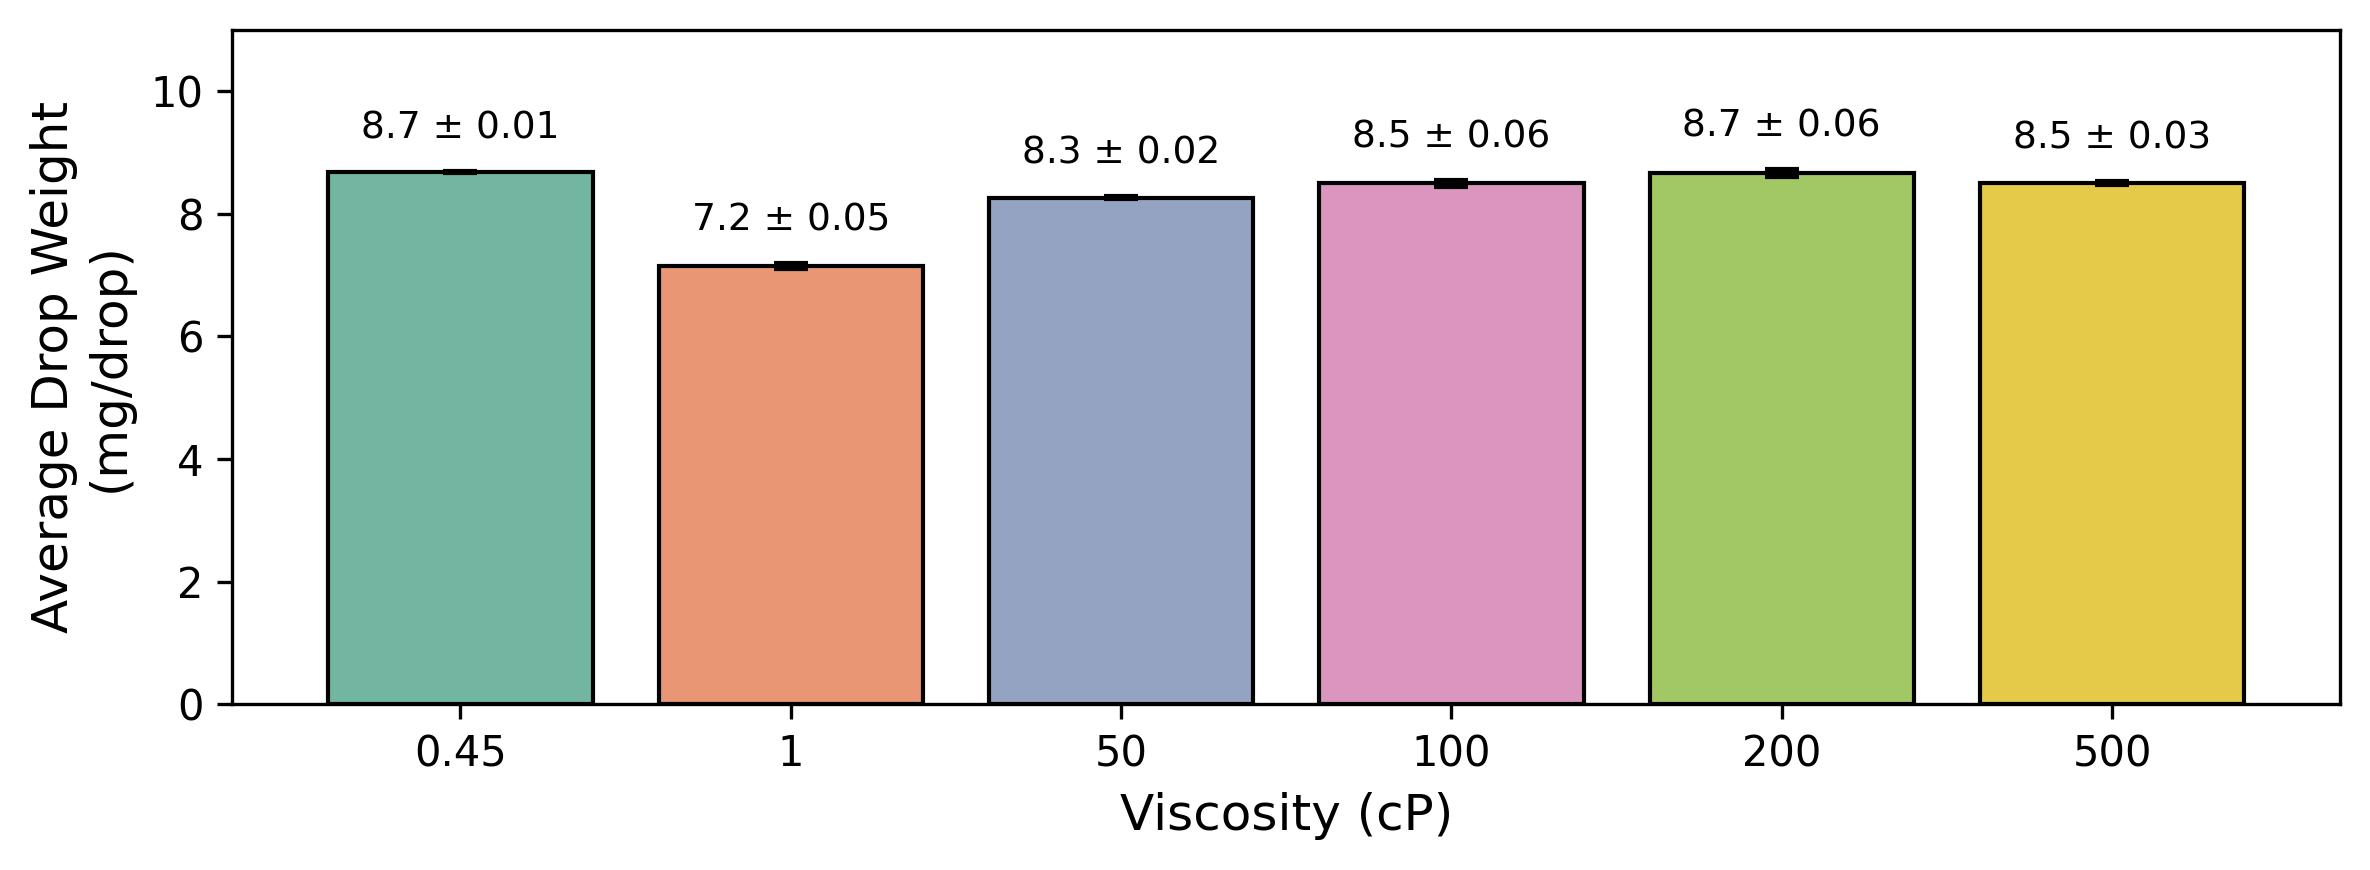

In [5]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Input CSVs
# =========================
viscosity_csvs = [
    "viscosity_accuracy_1ml_per_min_0.45cP_small_1.csv",
    "viscosity_accuracy_1ml_per_min_0.45cP_small_2.csv",
    "viscosity_accuracy_1ml_per_min_0.45cP_small_3.csv",
    "viscosity_accuracy_1ml_per_min_1cP_small_1.csv",
    "viscosity_accuracy_1ml_per_min_1cP_small_2.csv",
    "viscosity_accuracy_1ml_per_min_1cP_small_3.csv",
    "viscosity_accuracy_1ml_per_min_50cP_small_1.csv",
    "viscosity_accuracy_1ml_per_min_50cP_small_2.csv",
    "viscosity_accuracy_1ml_per_min_50cP_small_3.csv",
    "viscosity_accuracy_1ml_per_min_100cP_small_1.csv",
    "viscosity_accuracy_1ml_per_min_100cP_small_2.csv",
    "viscosity_accuracy_1ml_per_min_100cP_small_3.csv",
    "viscosity_accuracy_1ml_per_min_200cP_small_1.csv",
    "viscosity_accuracy_1ml_per_min_200cP_small_2.csv",
    "viscosity_accuracy_1ml_per_min_200cP_small_3.csv",
    "viscosity_accuracy_1ml_per_min_200cP_small_4.csv",
    "viscosity_accuracy_1ml_per_min_500cP_small_1.csv",
    "viscosity_accuracy_1ml_per_min_500cP_small_2.csv",
    "viscosity_accuracy_1ml_per_min_500cP_small_3.csv",
    "viscosity_accuracy_1ml_per_min_500cP_small_4.csv",
    "viscosity_accuracy_1ml_per_min_500cP_small_5.csv"
]

all_csv_files = viscosity_csvs

# =========================
# Helpers
# =========================
def _linfit_r2(x, y):
    """Simple linear fit y = a*x + b with R^2."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2:
        return np.nan, np.nan, np.nan
    a, b = np.polyfit(x[m], y[m], 1)
    yhat = a * x[m] + b
    ss_res = np.sum((y[m] - yhat)**2)
    ss_tot = np.sum((y[m] - y[m].mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    return a, b, r2

def _get_drop_series(df):
    for col in ["drop_counter", "vernier_drop", "drops", "Drop Count", "Counter"]:
        if col in df.columns:
            return pd.to_numeric(df[col], errors="coerce").ffill().fillna(0)
    raise KeyError("No drop counter column found!")

def _first_drop_index(drops: pd.Series) -> int:
    d = drops.to_numpy()
    diffs = np.diff(d, prepend=d[0])
    pos = np.flatnonzero(diffs > 0)
    return int(pos[0]) if len(pos) else 0

def extract_metadata(file):
    basename = os.path.basename(file).lower()
    viscosity, surface = None, "Unknown"
    if "viscosity" in basename:
        m = re.search(r"_([0-9]+(?:\.[0-9]+)?)cp", basename)
        viscosity = float(m.group(1)) if m else None
        surface = "Small" if "small" in basename else ("Big" if "big" in basename else "Unknown")
    else:
        viscosity, surface = 1.0, "Big"
    return viscosity, surface

def calculate_mg_per_drop(file):
    if not os.path.exists(file):
        return None, None
    df = pd.read_csv(file)
    if "weight" not in df.columns:
        return None, None

    weight = pd.to_numeric(df["weight"], errors="coerce")
    drops = _get_drop_series(df)

    # align start
    start_idx = 0
    if "timestamp" in df.columns:
        i_first = _first_drop_index(drops)
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        if df["timestamp"].notna().any():
            first_ts = df["timestamp"].iloc[i_first] if i_first < len(df) else df["timestamp"].dropna().iloc[0]
            if pd.isna(first_ts):
                first_ts = df["timestamp"].dropna().iloc[0]
            start_ts = first_ts - pd.Timedelta(seconds=1)
            start_idx = int(df["timestamp"].searchsorted(start_ts, side="left"))

    weight = weight.iloc[start_idx:].reset_index(drop=True)
    drops = drops.iloc[start_idx:].reset_index(drop=True)
    if len(drops) == 0 or len(weight) == 0:
        return None, None

    drops = drops - drops.iloc[0]  # rebase
    a, b, r2 = _linfit_r2(drops.to_numpy(), weight.to_numpy())
    if not np.isfinite(a):
        return None, None
    return a * 1000.0, r2  # mg/drop


# =========================
# Process all files
# =========================
data_records = []
for file in all_csv_files:
    viscosity, surface = extract_metadata(file)
    mg_per_drop, r2 = calculate_mg_per_drop(file)
    if viscosity is not None and mg_per_drop is not None:
        data_records.append({
            "Filename": os.path.basename(file),
            "Viscosity (cP)": float(viscosity),
            "Surface": surface,
            "mg/drop": mg_per_drop,
            "R²": r2
        })

df_results = pd.DataFrame(data_records)
if not df_results.empty:
    df_results["Viscosity (cP)"] = df_results["Viscosity (cP)"].astype(float).round(2)

print("\n=== Processed Data (replicates) ===")
print(df_results.sort_values(["Viscosity (cP)", "Filename"]).to_string(index=False))


# =========================
# Summarize & Plot
# =========================
summary = (
    df_results.groupby("Viscosity (cP)", as_index=False)
    .agg(**{
        "Average (mg/drop)": ("mg/drop", "mean"),
        "Std Dev": ("mg/drop", "std"),
        "Replicates": ("mg/drop", "count"),
    })
    .sort_values("Viscosity (cP)")
)

summary["ViscLabel"] = summary["Viscosity (cP)"].map(lambda v: f"{v:g}")
order = summary["ViscLabel"].tolist()

plt.figure(figsize=(8, 3), dpi=300, facecolor="white")
ax = sns.barplot(
    data=summary,
    x="ViscLabel",
    y="Average (mg/drop)",
    order=order,
    palette="Set2",
    edgecolor="black"
)

# Error bars
xs = [p.get_x() + p.get_width()/2 for p in ax.patches]
ax.errorbar(
    xs,
    summary["Average (mg/drop)"],
    yerr=summary["Std Dev"],
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=4,
    zorder=10
)

# Annotations
for x, mean, sd in zip(xs, summary["Average (mg/drop)"], summary["Std Dev"]):
    if np.isfinite(mean) and np.isfinite(sd):
        ax.text(
            x,
            mean + sd + 0.4,
            f"{mean:.1f} ± {sd:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_ylabel("Average Drop Weight\n(mg/drop)", fontsize=12)
ax.set_xlabel("Viscosity (cP)", fontsize=12)
ax.set_xticklabels(order, fontsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.set_ylim(0, 11)

plt.tight_layout()
plt.show()
